In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import the wordcloud library
from wordcloud import WordCloud
import re
import nltk

from pprint import pprint

# Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

# spacy for lemmatization
import spacy

# Plotting tools
import pyLDAvis
import pyLDAvis.gensim  # don't skip this
%matplotlib inline

# Enable logging for gensim - optional
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.ERROR)

import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Emile\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
import os

In [7]:
# Load in the dataframe
print(os.getcwd())
df = pd.read_csv("google_alerts/yourmoralsalerts/data/alertlinks_0.csv")
df = df.dropna(axis = 0, subset=['Text'])

c:\Users\Emile\Documents\Polytechnique\STAGES\3A\ghent_neuro\yourmoraldilemmas


In [8]:
df = df[df['Reachable']]

In [9]:
df

,Links,Reachable,Code,Text,Date
1,https://www.programme-television.org/news-tv/I...,True,200,Les People\nIci tout commence : Mehdi sous le ...,"Fri, 06 Jan 2023 19:24:55 -0000"
2,https://www.philomag.com/articles/leurope-et-l...,True,200,L’Europe et la guerre en Ukraine vues par un p...,"Fri, 06 Jan 2023 19:24:55 -0000"
6,https://www.latribune.ca/2023/01/13/captivant-...,True,200,Deux couples aux antipodes des privilèges fina...,"Fri, 13 Jan 2023 15:06:42 -0000"
7,https://www.radiofrance.fr/franceinter/podcast...,True,200,La philosophe Laurence Devillairs explique pou...,"Fri, 13 Jan 2023 15:06:42 -0000"
8,https://www.lesoleil.com/2023/01/13/captivant-...,True,200,Deux couples aux antipodes des privilèges fina...,"Sat, 14 Jan 2023 15:04:51 -0000"
...,...,...,...,...,...
150,https://www.crumpe.com/2023/08/le-realisateur-...,True,200,[ad_1]\nL’égaliseur 3 est commercialisé comme ...,"Fri, 25 Aug 2023 15:15:03 -0000"
151,https://www.notretemps.com/depeches/turquie-qu...,True,200,"A Sciences Po Paris, la mobilisation pro-pales...","Sun, 27 Aug 2023 15:13:40 -0000"
152,https://www.france-catholique.fr/Le-cote-catho...,True,200,"Dernièrement, j’ai lu coup sur coup deux roman...","Mon, 28 Aug 2023 15:15:06 -0000"
153,https://www.lemagducine.fr/cinema/critiques-fi...,True,200,"Présenté à la Mostra de Venise en 2022, Quand ...","Wed, 30 Aug 2023 15:17:22 -0000"


In [15]:
data = df['Text'].values.tolist()

In [16]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))  # deacc=True removes punctuations

data_words = list(sent_to_words(data))

print(data_words[:1])

[['les', 'people', 'ici', 'tout', 'commence', 'mehdi', 'sous', 'le', 'choc', 'face', 'une', 'douloureuse', 'trahison', 'le', 'resume', 'en', 'avance', 'du', 'janvier', 'spoilers', 'deva', 'et', 'david', 'se', 'retrouvent', 'face', 'un', 'dilemme', 'moral', 'delicat', 'jasmine', 'doit', 'rattraper', 'le', 'quiproquo', 'de', 'la', 'veille', 'avec', 'la', 'galette', 'des', 'rois', 'mehdi', 'decouvre', 'la', 'verite', 'sur', 'son', 'elimination', 'du', 'concours', 'de', 'commis', 'sous', 'tension', 'emmanuel', 'teyssier', 'se', 'met', 'il', 'en', 'danger', 'voici', 'les', 'temps', 'forts', 'de', 'episode', 'ici', 'tout', 'commence', 'du', 'janvier', 'tf', 'david', 'passe', 'la', 'nuit', 'avec', 'deva', 'chez', 'lisandro', 'alors', 'qu', 'il', 'est', 'sur', 'le', 'point', 'de', 'quitter', 'la', 'maison', 'en', 'catimini', 'il', 'ne', 'resiste', 'pas', 'envie', 'de', 'prendre', 'une', 'part', 'de', 'galette', 'dans', 'la', 'cuisine', 'le', 'couple', 'la', 'desagreable', 'surprise', 'de', 'vo

In [17]:
stop_words = set(nltk.corpus.stopwords.words('french'))

In [18]:
# Build the bigram and trigram models
bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100) # higher threshold fewer phrases.
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)  

# Faster way to get a sentence clubbed as a trigram/bigram
bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

# See trigram example
print(trigram_mod[bigram_mod[data_words[0]]])

['les', 'people', 'ici', 'tout', 'commence', 'mehdi', 'sous', 'le', 'choc', 'face', 'une', 'douloureuse', 'trahison', 'le', 'resume', 'en', 'avance', 'du', 'janvier', 'spoilers', 'deva', 'et', 'david', 'se', 'retrouvent', 'face', 'un', 'dilemme_moral', 'delicat', 'jasmine', 'doit', 'rattraper', 'le', 'quiproquo', 'de', 'la', 'veille', 'avec', 'la', 'galette', 'des', 'rois', 'mehdi', 'decouvre', 'la', 'verite', 'sur', 'son', 'elimination', 'du', 'concours', 'de', 'commis', 'sous', 'tension', 'emmanuel', 'teyssier', 'se', 'met', 'il', 'en', 'danger', 'voici', 'les', 'temps', 'forts', 'de', 'episode', 'ici', 'tout', 'commence', 'du', 'janvier', 'tf', 'david', 'passe', 'la', 'nuit', 'avec', 'deva', 'chez', 'lisandro', 'alors', 'qu', 'il', 'est', 'sur', 'le', 'point', 'de', 'quitter', 'la', 'maison', 'en', 'catimini', 'il', 'ne', 'resiste', 'pas', 'envie', 'de', 'prendre', 'une', 'part', 'de', 'galette', 'dans', 'la', 'cuisine', 'le', 'couple', 'la', 'desagreable', 'surprise', 'de', 'voir',

In [19]:
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """https://spacy.io/api/annotation"""
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent)) 
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return texts_out

In [20]:
# Remove Stop Words
data_words_nostops = remove_stopwords(data_words)

# Form Bigrams
data_words_bigrams = make_bigrams(data_words_nostops)

# Initialize spacy 'fr' model, keeping only tagger component (for efficiency)
# python3 -m spacy download en
nlp = spacy.load("fr_core_news_sm")

# Do lemmatization keeping only noun, adj, vb, adv
data_lemmatized = lemmatization(data_words_bigrams, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV'])

print(data_lemmatized[:1])

[['people', 'ici', 'commence', 'mehdi', 'choc', 'face', 'douloureux', 'trahison', 'resume', 'avance', 'janvier', 'spoiler', 'deva', 'david', 'retrouver', 'face', 'dilemme_moral', 'delicat', 'jasmin', 'devoir', 'rattraper', 'quiproquo', 'veille', 'galette', 'roi', 'mehdi', 'decouvre', 'verite', 'elimination', 'concours', 'commettre', 'tension', 'emmanuel', 'teyssier', 'mettre', 'danger', 'voici', 'temps', 'fort', 'episod', 'ici', 'commence', 'janvier', 'tf', 'david', 'passer', 'nuit', 'deva', 'lisandro', 'alors', 'point', 'quitter', 'maison', 'catimini', 'resist', 'envie', 'prendre', 'part', 'galett', 'cuisine', 'coupl', 'desagreable', 'surprise', 'voir', 'esteban', 'dejer', 'debout', 'david', 'demande', 'esteban', 'dire', 'lisandro', 'petit', 'garcon', 'exiger', 'echange', 'coffret', 'double', 'clotilde', 'annonc', 'liste', 'commettre', 'retenir', 'hortens', 'enzo', 'samier', 'kelly', 'jury', 'repecher', 'ethan', 'pallier', 'retraire', 'anai', 'salome', 'samier', 'rapproche', 'ancien',

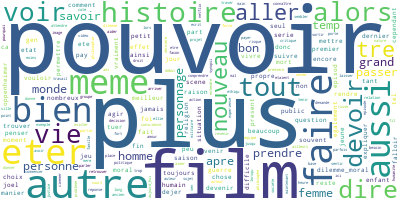

In [21]:

# Join the different processed titles together.
long_string = ','.join([','.join(text) for text in data_lemmatized])
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')
# Generate a word cloud
wordcloud.generate(long_string)
# Visualize the word cloud
wordcloud.to_image()


In [22]:
# Create Dictionary
id2word = corpora.Dictionary(data_lemmatized)

# Create Corpus
texts = data_lemmatized

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# View
print(corpus[:1])

[[(0, 1), (1, 2), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 4), (16, 1), (17, 1), (18, 4), (19, 1), (20, 1), (21, 1), (22, 2), (23, 1), (24, 2), (25, 2), (26, 3), (27, 3), (28, 1), (29, 1), (30, 1), (31, 2), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 2), (42, 1), (43, 1), (44, 1), (45, 2), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 4), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 2), (58, 1), (59, 4), (60, 4), (61, 1), (62, 1), (63, 2), (64, 1), (65, 2), (66, 1), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 1), (73, 2), (74, 3), (75, 1), (76, 1), (77, 1), (78, 1), (79, 8), (80, 1), (81, 3), (82, 1), (83, 2), (84, 1), (85, 1), (86, 1), (87, 3), (88, 1), (89, 1), (90, 1), (91, 2), (92, 1), (93, 1), (94, 1), (95, 1), (96, 4), (97, 1), (98, 1), (99, 3), (100, 1), (101, 2), (102, 1), (103, 1), (104, 1), (105, 1), (106, 1), (107, 1), (108, 1), (109, 3), (110, 3)

In [23]:
# Human readable format of corpus (term-frequency)
[[(id2word[id], freq) for id, freq in cp] for cp in corpus[:1]]

[[('accepter', 1),
  ('actu', 2),
  ('adoucir', 1),
  ('affronter', 1),
  ('agir', 1),
  ('aide', 1),
  ('ajout', 1),
  ('alcoolism', 1),
  ('alors', 1),
  ('an', 1),
  ('anai', 1),
  ('ancien', 1),
  ('angry', 1),
  ('animer', 1),
  ('annonc', 1),
  ('annonce', 4),
  ('annoncer', 1),
  ('apprendre', 1),
  ('apre', 4),
  ('apres_avoir', 1),
  ('arriver', 1),
  ('auguste', 1),
  ('aussi', 2),
  ('autour', 1),
  ('autre', 2),
  ('avance', 2),
  ('avoir', 3),
  ('avouer', 3),
  ('balader', 1),
  ('battr', 1),
  ('beau', 1),
  ('bien', 2),
  ('binome', 1),
  ('boit', 1),
  ('brigade', 1),
  ('bruxelle', 1),
  ('cageot', 1),
  ('camarade', 1),
  ('camp', 1),
  ('carrelage', 1),
  ('catimini', 1),
  ('cause', 2),
  ('ced', 1),
  ('ceder', 1),
  ('cell', 1),
  ('cercle', 2),
  ('cet_episode', 1),
  ('chambre', 1),
  ('championnat', 1),
  ('change', 1),
  ('chantage', 1),
  ('chef', 4),
  ('choc', 1),
  ('choisir', 1),
  ('circonstance', 1),
  ('clair', 1),
  ('clash', 1),
  ('clotilde', 2),
 

In [24]:
# Build LDA model
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=6, 
                                           update_every=1,
                                           chunksize=50,
                                           passes=10,
                                           alpha='auto',
                                           per_word_topics=True)

In [25]:
# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.016*"film" + 0.010*"plus" + 0.006*"histoire" + 0.006*"eter" + '
  '0.005*"pouvoir" + 0.005*"oppenheimer" + 0.004*"faire" + 0.004*"vie" + '
  '0.004*"tout" + 0.004*"dilemme_moral"'),
 (1,
  '0.012*"guerre" + 0.012*"pouvoir" + 0.009*"plus" + 0.009*"russie" + '
  '0.007*"ukrain" + 0.006*"autre" + 0.006*"meme" + 0.005*"faire" + '
  '0.005*"bien" + 0.005*"russe"'),
 (2,
  '0.010*"ecrit" + 0.005*"synopsi" + 0.005*"realis" + 0.005*"synopsis" + '
  '0.005*"debuts" + 0.004*"realise" + 0.004*"netflix" + 0.004*"an" + '
  '0.003*"sortie" + 0.003*"determiner"'),
 (3,
  '0.007*"jure" + 0.007*"hoult" + 0.005*"jouer" + 0.005*"proce" + '
  '0.004*"deutch" + 0.004*"serbe" + 0.003*"rick" + 0.003*"serbie" + '
  '0.003*"eastwood" + 0.003*"zoey"'),
 (4,
  '0.008*"plus" + 0.005*"pouvoir" + 0.005*"ouragan" + 0.005*"aller" + '
  '0.004*"enfant" + 0.004*"club" + 0.004*"autre" + 0.003*"florid" + '
  '0.003*"tre" + 0.003*"faire"'),
 (5,
  '0.012*"pouvoir" + 0.011*"plus" + 0.006*"faire" + 0.006*"autre" +

In [26]:
# Compute Perplexity
print('\nPerplexity: ', lda_model.log_perplexity(corpus))  # a measure of how good the model is. lower the better.

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda_model, texts=data_lemmatized, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)


Perplexity:  -8.55407515322953

Coherence Score:  0.4290803188868039


In [27]:
# Visualize the topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.130952  0.091810       1        1  32.212749
1     -0.083464 -0.031092       2        1  26.239897
5     -0.107976  0.045482       3        1  23.799859
4      0.012558 -0.187268       4        1   9.981864
2      0.198820  0.087586       5        1   6.707174
3      0.111013 -0.006519       6        1   1.058457, topic_info=            Term        Freq       Total Category  logprob  loglift
774         film  241.000000  241.000000  Default  30.0000  30.0000
503       guerre  157.000000  157.000000  Default  29.0000  29.0000
665       russie  104.000000  104.000000  Default  28.0000  28.0000
1284       ecrit   51.000000   51.000000  Default  27.0000  27.0000
717       ukrain   78.000000   78.000000  Default  26.0000  26.0000
...          ...         ...         ...      ...      ...      ...
4901  influencer    0.949592    5.130437   Topic6  -6.1665   2.8614
167         jury    0.764171    4.420478   Topic6  -6.3837   2.7931
4546      leslie    0.650324    3.373894   Topic6  -6.5451   2.9020
6031    retrouve    0.691607    7.969115   Topic6  -6.4835   2.1040
2860     liberer    0.642294    7.755323   Topic6  -6.5575   2.0573

[395 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
1228      1  0.819436        _
1228      3  0.170716        _
325       2  0.930589   actuel
9096      5  0.864151     adil
6599      4  0.761421      afp
...     ...       ...      ...
317       3  0.274952  vouloir
317       4  0.073321  vouloir
7954      5  0.966658   worlds
2834      5  0.940179      you
6038      6  0.497313     zoey

[613 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 6, 5, 3, 4])

In [28]:
def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):
    """
    Compute c_v coherence for various number of topics

    Parameters:
    ----------
    dictionary : Gensim dictionary
    corpus : Gensim corpus
    texts : List of input texts
    limit : Max num of topics

    Returns:
    -------
    model_list : List of LDA topic models
    coherence_values : Coherence values corresponding to the LDA model with respective number of topics
    """
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=num_topics, 
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha='auto',
                                           per_word_topics=True)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

In [29]:
# Can take a long time to run.
model_list, coherence_values = compute_coherence_values(dictionary=id2word, corpus=corpus, texts=data_lemmatized, start=3, limit=40, step=1)

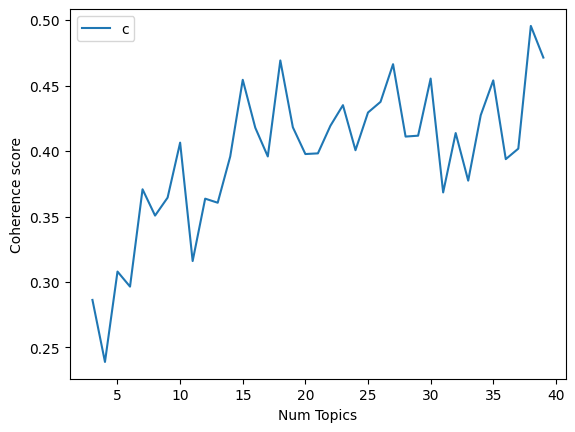

In [30]:
# Show graph
limit=40
start=3
step=1
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [36]:
np.argmax(coherence_values[:10])

7

In [37]:
final_model = model_list[np.argmax(coherence_values)]

In [38]:
# Visualize the topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(final_model, corpus, id2word)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.354275 -0.049066       1        1  23.236394
9      0.327278  0.035651       2        1  17.245986
34     0.295982 -0.044718       3        1  12.725555
6      0.293861 -0.037815       4        1   8.528336
16     0.203347 -0.192061       5        1   6.209139
13     0.109080  0.171350       6        1   4.360678
23     0.159057  0.221432       7        1   3.681234
10     0.070046  0.059437       8        1   2.748240
1      0.023281  0.060970       9        1   2.513323
18     0.025415 -0.060910      10        1   2.492551
17     0.058372 -0.049816      11        1   2.271849
12     0.044075  0.134757      12        1   2.177816
33    -0.038580 -0.056353      13        1   1.490579
15    -0.000507 -0.103457      14        1   1.298362
19    -0.057028  0.009439      15        1   1.180172
37    -0.033832 -0.033013      16        1   1.068314
22    -0.067046 -0.002828      17        1   1.048320
7     -0.076995 -0.004835      18        1   0.840684
3     -0.094061 -0.004704      19        1   0.797403
35    -0.063012 -0.015611      20        1   0.644669
27    -0.096373 -0.001970      21        1   0.544350
26    -0.094293 -0.006402      22        1   0.480658
25    -0.097830 -0.003996      23        1   0.449400
21    -0.090056 -0.006628      24        1   0.371881
32    -0.075294  0.002321      25        1   0.355278
20    -0.085800 -0.001112      26        1   0.216122
4     -0.090151 -0.000168      27        1   0.191771
28    -0.084411 -0.002115      28        1   0.140346
11    -0.083654 -0.001555      29        1   0.113245
5     -0.081639 -0.003590      30        1   0.107868
36    -0.091467 -0.001390      31        1   0.104080
0     -0.083052 -0.001352      32        1   0.084546
29    -0.081422 -0.002288      33        1   0.079225
24    -0.081768 -0.001244      34        1   0.074369
14    -0.081257 -0.001405      35        1   0.065492
8     -0.080855 -0.001451      36        1   0.052901
31    -0.076829 -0.001755      37        1   0.004612
30    -0.076858 -0.001751      38        1   0.004253, topic_info=                Term        Freq       Total Category  logprob  loglift
774             film  323.000000  323.000000  Default  30.0000  30.0000
503           guerre  147.000000  147.000000  Default  29.0000  29.0000
1284           ecrit   79.000000   79.000000  Default  28.0000  28.0000
665           russie  100.000000  100.000000  Default  27.0000  27.0000
6244     oppenheimer   58.000000   58.000000  Default  26.0000  26.0000
...              ...         ...         ...      ...      ...      ...
461             eter    0.000184  233.548062  Topic38  -9.1992  -3.9895
97            devoir    0.000184  148.635290  Topic38  -9.1992  -3.5376
142            grand    0.000184  150.874734  Topic38  -9.1992  -3.5526
6124   bande_annonce    0.000184    7.516556  Topic38  -9.1993  -0.5532
4462  valeurs_morale    0.000184   12.346611  Topic38  -9.1993  -1.0495

[1907 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
1228      1  0.899569         _
1228      5  0.097251         _
4938      5  0.481022    abonne
4938     11  0.481022    abonne
2663      3  0.860069   abonner
...     ...       ...       ...
7826      6  0.967803    wagner
1427     26  0.670189  whoreson
1428     26  0.558310   witcher
2834     31  0.729260       you
6038     21  0.735742      zoey

[2371 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 10, 35, 7, 17, 14, 24, 11, 2, 19, 18, 13, 34, 16, 20, 38, 23, 8, 4, 36, 28, 27, 26, 22, 33, 21, 5, 29, 12, 6, 37, 1, 30, 25, 15, 9, 32, 31])

In [39]:
# Visualize the topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(model_list[6], corpus, id2word)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.154505  0.060273       1        1  28.161747
7      0.140164  0.105588       2        1  19.135713
3      0.065524  0.009700       3        1  16.715516
5      0.091230 -0.206297       4        1   9.693844
2     -0.017290 -0.046013       5        1   8.799401
8     -0.097861  0.116016       6        1   8.458813
0     -0.071117 -0.004548       7        1   6.062324
6     -0.157973 -0.011538       8        1   2.808378
4     -0.107182 -0.023181       9        1   0.164265, topic_info=               Term        Freq       Total Category  logprob  loglift
774            film  252.000000  252.000000  Default  30.0000  30.0000
503          guerre  125.000000  125.000000  Default  29.0000  29.0000
665          russie   84.000000   84.000000  Default  28.0000  28.0000
717          ukrain   65.000000   65.000000  Default  27.0000  27.0000
2348          russe   51.000000   51.000000  Default  26.0000  26.0000
...             ...         ...         ...      ...      ...      ...
7356  charismatique    0.038298    0.773834   Topic9  -7.5140   3.4055
7368        envieux    0.038298    0.773835   Topic9  -7.5140   3.4055
7382         messin    0.038298    0.773835   Topic9  -7.5140   3.4055
2437         rapide    0.060102    7.341889   Topic9  -7.0634   1.6061
45           cercle    0.038300    1.620160   Topic9  -7.5140   2.6666

[565 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
1228      1  0.286411       _
1228      4  0.286411       _
1228      5  0.393815       _
2823      8  0.864391  access
324       1  0.585338  action
...     ...       ...     ...
7954      5  0.893354  worlds
8681      7  0.863630     xbo
2834      3  0.219029     you
2834      8  0.657088     you
3190      2  0.935028    zone

[1021 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 8, 4, 6, 3, 9, 1, 7, 5])

In [40]:
coherence_values[6]

0.3644297608839894

## Testing empath

In [1]:
from empath import Empath
lexicon = Empath()

In [11]:
df['Text']

1      Les People\nIci tout commence : Mehdi sous le ...
2      L’Europe et la guerre en Ukraine vues par un p...
6      Deux couples aux antipodes des privilèges fina...
7      La philosophe Laurence Devillairs explique pou...
8      Deux couples aux antipodes des privilèges fina...
                             ...                        
150    [ad_1]\nL’égaliseur 3 est commercialisé comme ...
151    A Sciences Po Paris, la mobilisation pro-pales...
152    Dernièrement, j’ai lu coup sur coup deux roman...
153    Présenté à la Mostra de Venise en 2022, Quand ...
155    « L’ouragan Idalia sera probablement un événem...
Name: Text, Length: 125, dtype: object

In [26]:
# Extract most likely categories with Empath
categories = lexicon.analyze(df['Text'].iloc[0], normalize=True)

# only keep the 10 best categories
categories = {k: v for k, v in sorted(categories.items(), key=lambda item: item[1], reverse=True)[:20]}

In [27]:
categories

{'alcohol': 0.010121457489878543,
 'liquid': 0.010121457489878543,
 'wedding': 0.009109311740890687,
 'family': 0.009109311740890687,
 'death': 0.009109311740890687,
 'youth': 0.009109311740890687,
 'children': 0.009109311740890687,
 'driving': 0.005060728744939271,
 'dispute': 0.004048582995951417,
 'vehicle': 0.004048582995951417,
 'car': 0.004048582995951417,
 'restaurant': 0.003036437246963563,
 'domestic_work': 0.0020242914979757085,
 'cheerfulness': 0.0020242914979757085,
 'occupation': 0.0020242914979757085,
 'horror': 0.0020242914979757085,
 'fear': 0.0020242914979757085,
 'childish': 0.0020242914979757085,
 'cooking': 0.0020242914979757085,
 'surprise': 0.0020242914979757085}

## Project texts on MFD dict

In [28]:
dict_path = "data/mfd2.0.dic"

In [48]:
# Load the dictionary
with open(dict_path, "r") as f:
    lines = f.readlines()

# Parse the dictionary
# The dictionary is a list of lines, each line is a word followed by a number between 1 and 10 corresponding to a category
# We will parse the dictionary into a dictionary of words and categories


class Category:
    def __init__(self, name):
        self.name = name
        self.words = {}
        self.ids = {}
    
    def add_type(self, num, type):
        self.words[num] = []
        self.ids[num] = type
    
    def add_word(self, word, category_number):
        self.words[category_number].append(word)

# Parse the dictionary
categories = {}
for line in lines[1:11]:
    line = line.split("\t")
    category_number = int(line[0])
    # delete the \n at the end of the line
    category_name, type = line[1].split(".")[0], line[1].split(".")[1][:-1]
    category = Category(category_name)
    category.add_type(category_number, type)
    categories[category_number] = category





In [49]:
for line in lines[12:]:
    word = line.split("\t")[0]
    num = int(line.split("\t")[1])
    categories[num].add_word(word, num)

In [50]:
categories[1]

In [51]:
for category in categories.values():
    print(category.name)
    for num, type in zip(category.ids.keys(),category.ids.values()):
        print(type)
        print(category.words[num][:10])
    print("\n")

care
virtue
['compassion', 'empathy', 'kindness', 'caring', 'generosity', 'benevolence', 'altruism', 'compassionate', 'nurture', 'gentleness']


care
vice
['harm', 'suffer', 'hurt', 'harmed', 'hurting', 'hurts', 'cruel', 'endanger', 'harming', 'harms']


fairness
virtue
['equality', 'fairness', 'justice', 'rights', 'equitable', 'civil rights', 'fairplay', 'impartiality', 'equal', 'fairminded']


fairness
vice
['cheat', 'unfair', 'cheating', 'unfairness', 'injustice', 'fraud', 'dishonest', 'unjust', 'cheated', 'fraudulent']


loyalty
virtue
['team player', 'player', 'patriot', 'loyal', 'loyalty', 'patriots', 'follower', 'fidelity', 'allegiance', 'ally']


loyalty
vice
['traitor', 'disloyal', 'treason', 'traitors', 'betray', 'betraying', 'betrayer', 'betrayers', 'unpatriotic', 'betrayed']


authority
virtue
['respect', 'obey', 'authority', 'obeyed', 'deference', 'reverence', 'respecting', 'obeying', 'tradition', 'adhere']


authority
vice
['disrespect', 'disobey', 'disobedience', 'anarch

In [ ]:
# Pearson correlation between the categories and 3 most relevant topics
from scipy.stats import pearsonr

# Get the topics
topics = final_model.show_topics(num_words=10, num_topics=6, formatted=False)

# Get the words of the topics
topics_words = []
for topic in topics:
    words = [word[0] for word in topic[1]]
    topics_words.append(words)

# Get the categories of the words
categories_words = {}
for category in categories.values():
    for num, type in zip(category.ids.keys(),category.ids.values()):
        for word in category.words[num]:
            categories_words[word] = type

# Compute the correlation between the categories and the topics
correlations = {}
for i, topic in enumerate(topics_words):
    correlations[i] = {}
    for word in topic:
        if word in categories_words.keys():
            correlations[i][word] = categories_words[word]
        else:
            correlations[i][word] = None

correlations